In [1]:
import pandas as pd

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
%matplotlib inline

In [4]:
import os
os.getcwd()

'C:\\Users\\billy'

In [9]:
!dir

 Volume in drive C has no label.
 Volume Serial Number is D8AC-63EE

 Directory of C:\Users\billy

28/01/2026  18:57    <DIR>          .
28/01/2026  18:57    <DIR>          ..
16/07/2025  11:33    <DIR>          .anaconda
24/07/2025  22:10    <DIR>          .conda
16/07/2025  11:34                25 .condarc
16/07/2025  11:33    <DIR>          .continuum
28/01/2026  18:33    <DIR>          .ipynb_checkpoints
16/07/2025  11:38    <DIR>          .ipython
22/07/2025  14:22    <DIR>          .jupyter
22/08/2025  14:01    <DIR>          .matplotlib
09/07/2025  13:25    <DIR>          .ms-ad
16/07/2025  11:39    <DIR>          .virtual_documents
15/09/2025  13:25    <DIR>          .vscode
28/01/2026  18:57            12,368 01_event_exploration.ipynb
09/07/2025  13:04    <DIR>          3D Objects
16/07/2025  11:38    <DIR>          anaconda3
22/07/2025  14:22    <DIR>          anaconda_projects
14/08/2025  09:53            36,190 Cleaned_Business_Info.xlsx
23/08/2025  12:32            17,626

In [25]:
users = pd.read_csv('users.csv')
subscriptions = pd.read_csv('subscriptions.csv')
events = pd.read_csv('events.csv')

In [28]:
users.info()
subscriptions.info()
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      100 non-null    int64 
 1   signup_date  100 non-null    object
 2   country      100 non-null    object
 3   plan         100 non-null    object
dtypes: int64(1), object(3)
memory usage: 3.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   user_id              100 non-null    int64 
 1   signup_date          100 non-null    object
 2   country              100 non-null    object
 3   plan                 100 non-null    object
 4   subscription_status  100 non-null    object
 5   revenue              100 non-null    int64 
 6   churn_date           26 non-null     object
dtypes: int64(2), object(5)
memory usage: 5.6+ KB
<class 

In [29]:
users = pd.read_csv('users.csv', parse_dates=['signup_date'])
subscriptions = pd.read_csv('subscriptions.csv', parse_dates=['signup_date','churn_date'])
events = pd.read_csv('events.csv', parse_dates=['event_date'])

In [31]:
subscriptions.head()
subscriptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   user_id              100 non-null    int64 
 1   signup_date          100 non-null    object
 2   country              100 non-null    object
 3   plan                 100 non-null    object
 4   subscription_status  100 non-null    object
 5   revenue              100 non-null    int64 
 6   churn_date           26 non-null     object
dtypes: int64(2), object(5)
memory usage: 5.6+ KB


In [34]:
print("Users table:")
display(users.head())

print("Subscriptions table:")
display(subscriptions.head())

print("Events table:")
display(events.head())


Users table:


,user_id,signup_date,country,plan
0,1,2022-01-01,USA,free
1,2,2022-01-02,India,free
2,3,2022-01-03,USA,pro
3,4,2022-01-04,India,pro
4,5,2022-01-05,USA,basic


Subscriptions table:


,user_id,signup_date,country,plan,subscription_status,revenue,churn_date
0,1,01/01/2022,USA,free,free,0,NaN
1,2,02/01/2022,India,free,free,0,NaN
2,3,03/01/2022,USA,pro,paid,50,NaN
3,4,04/01/2022,India,pro,paid,50,NaN
4,5,05/01/2022,USA,basic,paid,20,NaN


Events table:


,user_id,event_date,event_type
0,20,01/01/2022 00:00,feature_C
1,98,01/01/2022 01:00,feature_A
2,32,01/01/2022 02:00,feature_A
3,60,01/01/2022 03:00,feature_A
4,78,01/01/2022 04:00,feature_A


In [37]:
print ('users shape:', users.shape)
print ('events shape:', events.shape)
print ('subscriptions shape:', subscriptions.shape)

users shape: (100, 4)
events shape: (1000, 3)
subscriptions shape: (100, 7)


In [38]:
#NOW IS TIME I EXPLORED THE EVENT TYPES AND FREQUENCY, SO THAT I;
#Lists all event_types I know what actions users take

#Counts how many times each event happens

#plots a bar chart of event frequencies

#Counts events per user → see active vs inactive users

#Calculates days from signup to first event → helps define activation



In [40]:
#Lists all event_types I know what actions users take

unique_events = events['event_type'].unique()
print("Unique event types:\n", unique_events)

Unique event types:
 ['feature_C' 'feature_A' 'login' 'feature_B']


In [41]:
#Counts how many times each event happens

event_counts = events['event_type'].value_counts().reset_index()
event_counts.columns = ['event_type', 'count']
print("\nEvent counts:\n", event_counts)


Event counts:
   event_type  count
0  feature_B    277
1  feature_C    262
2      login    243
3  feature_A    218


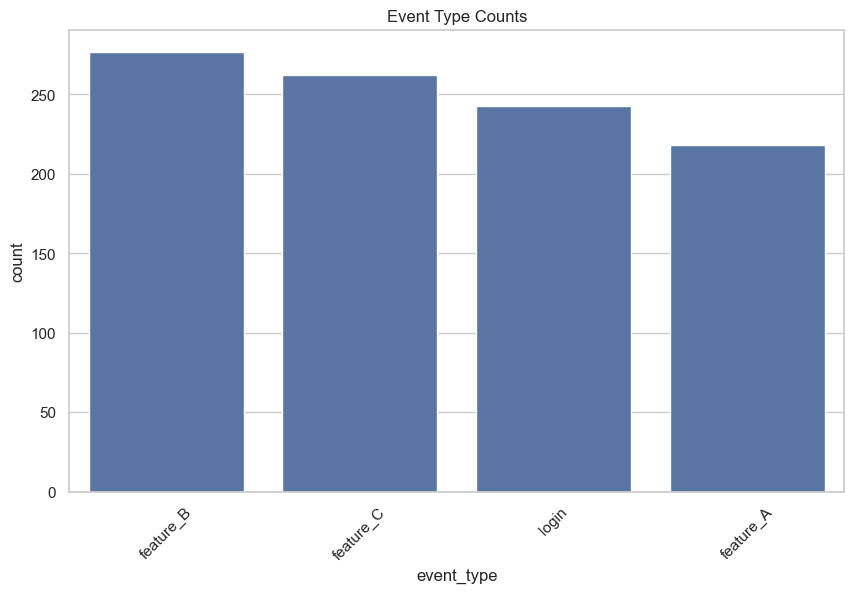

In [42]:
#plot a bar chart of event frequencies

plt.figure(figsize=(10,6))
sns.barplot(data=event_counts, x='event_type', y='count')
plt.xticks(rotation=45)
plt.title('Event Type Counts')
plt.show()

In [43]:
#Count events per user → see active vs inactive users

user_event_counts = events.groupby('user_id').size().reset_index(name='total_events')
print("\nEvents per user:\n", user_event_counts.describe())

#FROM THE RESULTS BELOW, THIS IS WHAT IS SHOWING; 
#User engagement is fairly consistent, with most users performing between 8 and 12 events.
#There are no completely inactive users, suggesting effective onboarding. 
#A subset of highly engaged users exists, indicating potential for strong retention.


Events per user:
           user_id  total_events
count  100.000000     100.00000
mean    50.500000      10.00000
std     29.011492       3.44363
min      1.000000       2.00000
25%     25.750000       8.00000
50%     50.500000      10.00000
75%     75.250000      12.25000
max    100.000000      18.00000


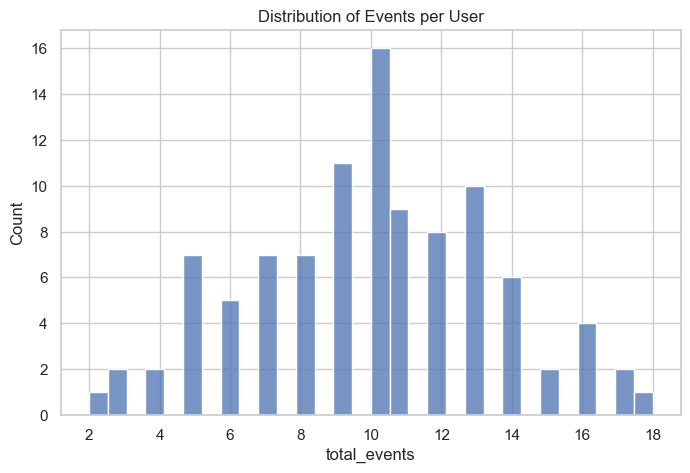

In [44]:
plt.figure(figsize=(8,5))
sns.histplot(user_event_counts['total_events'], bins=30, kde=False)
plt.title('Distribution of Events per User')
plt.show()

In [46]:
#Calculates days from signup to first event → helps define activation

print(first_event.dtypes)


user_id                 int64
event_date             object
signup_date    datetime64[ns]
dtype: object


In [49]:
#Since the 'event_date' is in text form, I'll have to change it to real date 
first_event['event_date'] = pd.to_datetime(
    first_event['event_date'],
    dayfirst=True
)
first_event.dtypes

user_id                 int64
event_date     datetime64[ns]
signup_date    datetime64[ns]
dtype: object

In [51]:
first_event['days_to_first_event'] = (
    first_event['event_date'] - first_event['signup_date']
).dt.days

first_event['days_to_first_event'].describe()
# From the results, for many users, events are happening BEFORE signup

#Which is logically impossible in a real SaaS product.

#So one (or more) of these is true:

# 1 Signup dates are wrong
# 2 Event dates are wrong
# 3 The dataset is synthetic or loosely simulated
# 4 Users may have events logged before “formal signup” (rare, but possible) 

count    100.000000
mean     -33.330000
std       33.374537
min      -98.000000
25%      -59.750000
50%      -29.000000
75%       -8.000000
max       32.000000
Name: days_to_first_event, dtype: float64

In [52]:
first_event.sort_values('days_to_first_event').head(10)


,user_id,event_date,signup_date,days_to_first_event
98,99,2022-01-01 12:00:00,2022-04-09,-98
97,98,2022-01-01 01:00:00,2022-04-08,-97
95,96,2022-01-03 23:00:00,2022-04-06,-93
92,93,2022-01-01 07:00:00,2022-04-03,-92
94,95,2022-01-06 18:00:00,2022-04-05,-89
89,90,2022-01-02 12:00:00,2022-03-31,-88
90,91,2022-01-03 11:00:00,2022-04-01,-88
91,92,2022-01-05 16:00:00,2022-04-02,-87
86,87,2022-01-04 12:00:00,2022-03-28,-83
80,81,2022-01-01 05:00:00,2022-03-22,-80


In [57]:
(first_event['days_to_first_event'] < 0).value_counts()
# This tells you how widespread the issue is.

days_to_first_event
True     83
False    17
Name: count, dtype: int64

In [54]:
clean_first_event = first_event[
    first_event['days_to_first_event'] >= 0
]
# We only trust events that happened after signup so I filtered out negative values

In [56]:
# Now heres the cleaned data

clean_first_event['days_to_first_event'].describe()

# And what should be understood is that a user is activated if they perform their first event within 1 day of signup

count    17.000000
mean     13.411765
std      10.665709
min       0.000000
25%       4.000000
50%      14.000000
75%      20.000000
max      32.000000
Name: days_to_first_event, dtype: float64

In [58]:
# Here I created an activation flag
clean_first_event['activated'] = (
    clean_first_event['days_to_first_event'] <= 1
).astype(int)


C:\Users\billy\AppData\Local\Temp\ipykernel_10664\2427364153.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_first_event['activated'] = (


In [59]:
clean_first_event = first_event[
    first_event['days_to_first_event'] >= 0
].copy()


In [60]:
clean_first_event['activated'] = (
    clean_first_event['days_to_first_event'] <= 1
).astype(int)


In [61]:
# Check activation rate ( this explians % of users who successfully activate
# and where onboarding may be failing)

clean_first_event['activated'].value_counts(normalize=True)


activated
0    0.764706
1    0.235294
Name: proportion, dtype: float64

In [63]:
# From the above report it shows that Only ~24% of users activate, ~76% drop off before reaching first value
# THIS IS A HUGE ONBOARDING PROBLEM!!!!

In [64]:
clean_first_event['days_to_first_event'].describe()

count    17.000000
mean     13.411765
std      10.665709
min       0.000000
25%       4.000000
50%      14.000000
75%      20.000000
max      32.000000
Name: days_to_first_event, dtype: float64

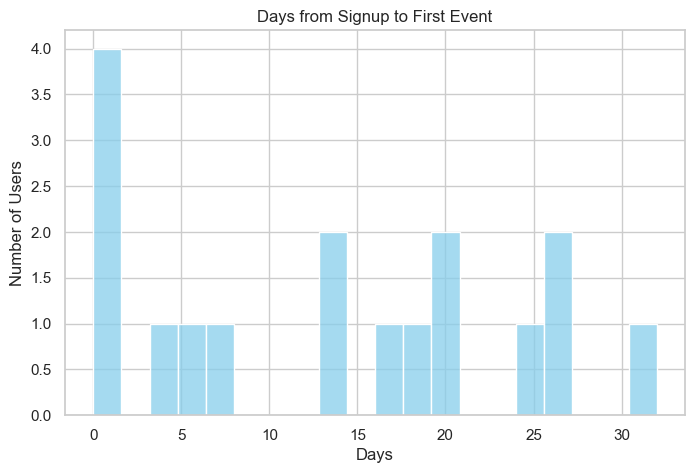

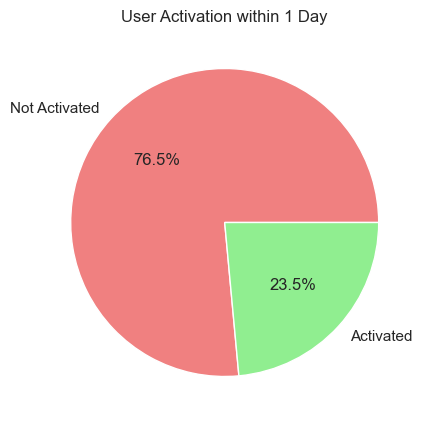

In [65]:
# Histogram of days to first event
plt.figure(figsize=(8,5))
sns.histplot(clean_first_event['days_to_first_event'], bins=20, kde=False, color='skyblue')
plt.title("Days from Signup to First Event")
plt.xlabel("Days")
plt.ylabel("Number of Users")
plt.show()

# Pie chart for activation
plt.figure(figsize=(5,5))
clean_first_event['activated'].value_counts().plot.pie(labels=['Not Activated','Activated'], autopct='%1.1f%%', colors=['lightcoral','lightgreen'])
plt.title("User Activation within 1 Day")
plt.ylabel("")
plt.show()